# 🌱 YOLO for Plant Pathology: A Hands‑On Tutorial

**Goal:** Introduce YOLO for vision tasks such as lesion detection, disease quantification, and phenotyping.

**Learning outcomes:**
- Understand what YOLO is and the tasks it supports.
- Run YOLO inference on plant pathology images.
- Train and evaluate a small custom YOLO model.
- Connect YOLO capabilities to real plant‑pathology applications.

# 1. What’s YOLO?

YOLO (**You Only Look Once**)
- looks at the whole image once with a single neural network and directly predicts where objects are and what they are.
- relative to two-stage object-detection algorithms, which first generate candidate object regions and then perform a second stage to classify and refine those regions.

**YOLO26 Architecture** (https://arxiv.org/pdf/2602.14582)

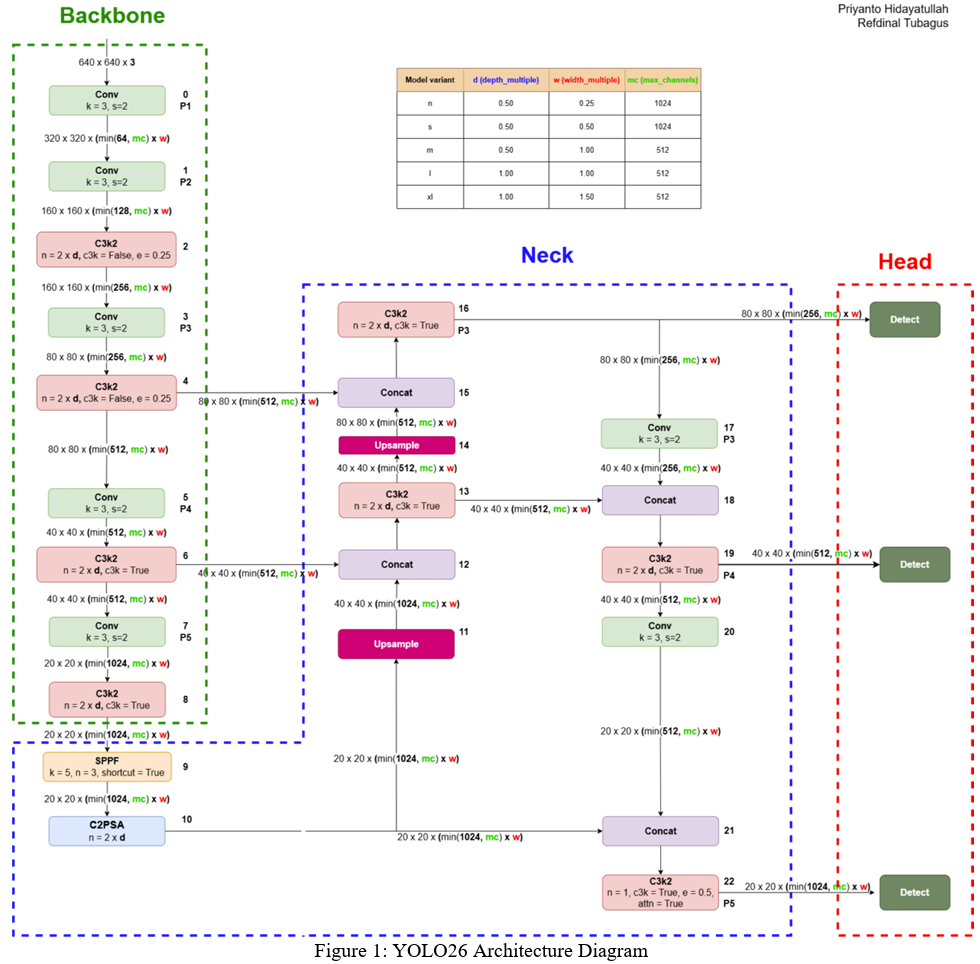

YOLO26 = Backbone for feature extraction + Neck for multi-scale feature fusion + Head for direct localization and classification

**YOLO versions** (https://docs.ultralytics.com/models/yolo26)

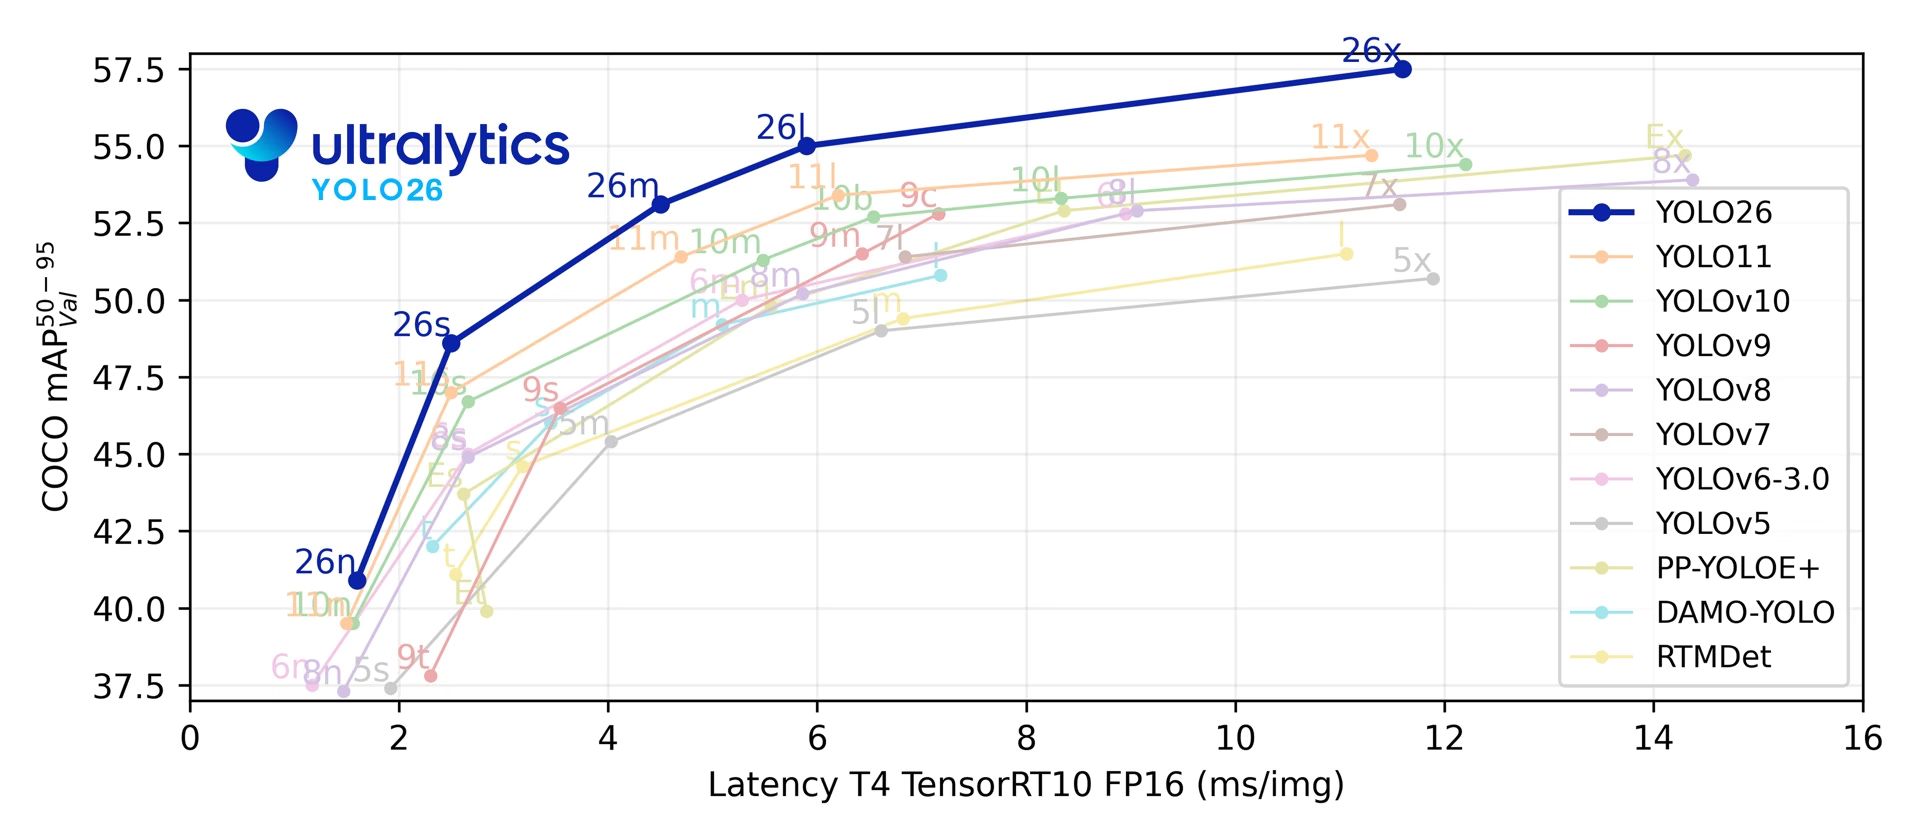

| Model Generation | Release Year | Primary Developer | Core Highlights |
| :--- | :--- | :--- | :--- |
| **Ultralytics YOLO26** | **2026** | Ultralytics | **Latest recommended SOTA.** Lighter and faster with native, NMS-free end-to-end inference and 43% faster CPU inference. |
| **Ultralytics YOLO11** | **2024** | Ultralytics | High-efficiency architecture delivering higher accuracy with fewer parameters. |
| **YOLOv10** | **2024** | Tsinghua University | Designed for real-time end-to-end object detection. |
| **YOLOv9** | **2024** | Chien-Yao Wang et al. | Introduced Programmable Gradient Information (PGI). |
| **Ultralytics YOLOv8** | **2023** | Ultralytics | Expanded the API to universally support instance segmentation, classification, pose estimation, and OBB. |
| **YOLOv5** | **2020** | Ultralytics | The first PyTorch-native implementation that streamlined training for developers. |
| **Legacy Models** | **2015–2022** | Various | Compatibility extends back to **YOLOv3**, **YOLOv6**, and **YOLOv7**, alongside non-YOLO vision models like RT-DETR and SAM. |


## YOLO suported tasks
https://docs.ultralytics.com/tasks


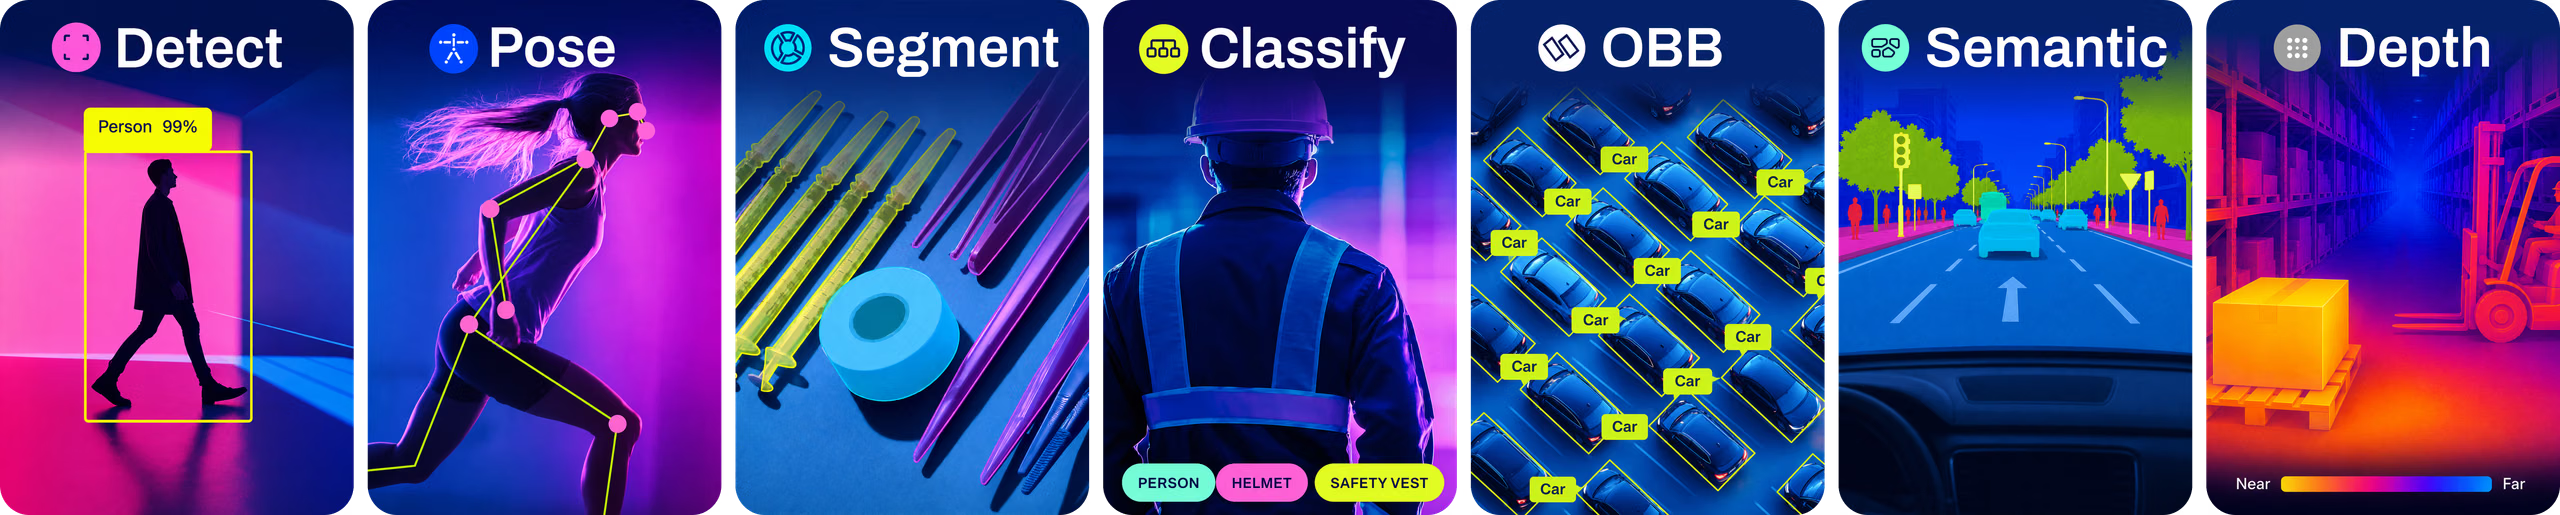

Each can be mapped to plant‑pathology use cases:

- **Object detection (Detect):**
  - Locate symptomatic leaves, fruits, lesions, or infected plants.
  - Example: Detect citrus canker lesions on leaves.

- **Instance segmentation (Segment):**
  - Produce masks for individual objects.
  - Example: Segment lesion areas to quantify disease severity.

- **Semantic segmentation (Semantic):**
  - Classify every pixel into categories (leaf, stem, soil, background).
  - Example: Analyze canopy coverage or distinguish healthy vs. diseased tissue.

- **Classification (Classify):**
  - Assign a label to an image or region.
  - Example: Classify disease type (e.g., early blight vs. late blight).

- **Pose estimation (Pose):**
  - Estimate keypoints and structure of articulated objects.
  - Example: Guide agricultural robots or arms to sample specific plant parts.

- **Depth estimation (Depth):**
  - Predict relative distance of scene elements.
  - Example: Study canopy structure, occlusion of symptoms, or robot navigation.

- **Oriented bounding boxes (OBB):**
  - Detect objects with rotated boxes.
  - Example: Capture elongated lesions on stems or streaks on leaves.

In this notebook, we will primarily focus on **instance segmention**, with a detailed section on training a custom segmentor for plant‑disease symptoms.

# 2. Setup tools



### Use GPU in Colab

Navigate to `Runtime` -> `Change runtime type` -> select your desired GPU under `Hardware accelerator`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training process.

In [19]:
# Check if we have we access to GPU, using nvidia-smi command
!nvidia-smi

Wed Oct  7 19:51:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             31W /   70W |     667MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install Ultralytics YOLO
We will use the **Ultralytics YOLO** implementation, which provides a simple Python API for training, validation, and prediction.

In [20]:
!pip install -q ultralytics

### Import YOLO
Import the YOLO class and some utilities for displaying images.

In [21]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

print("Ultralytics YOLO version loaded.")

Ultralytics YOLO version loaded.


# 3. Prepare data

### download data

In [22]:
# First install gdown (if not already installed)
!pip install -q gdown

# File ID from your new link
file_id = "1yYnOxfidM3x4qorikOYNUjTgKzEe8kiR"

# Build the download URL
url = f"https://drive.google.com/uc?id={file_id}"

# Download it — name it appropriately (e.g. data.zip)
!gdown {url} -O data.zip

# Unzip into a folder (say “data”)
!unzip -qo data.zip -d data # -o overwrite existing files without asking for confirmation

# Optionally list some files to check
!ls -R data | head -20


Downloading...
From: https://drive.google.com/uc?id=1yYnOxfidM3x4qorikOYNUjTgKzEe8kiR
To: /content/data.zip
100% 4.26M/4.26M [00:00<00:00, 22.2MB/s]
data:
small_dataset

data/small_dataset:
data.yaml
test
train
valid

data/small_dataset/test:
images
labels

data/small_dataset/test/images:
b-121-_jpg.rf.32a36b5c4d8dc98190cd6ff22c1b1dbe.jpg
b-126-_jpg.rf.85521dca81a31b2378977cad9da0a9c4.jpg
b-128-_jpg.rf.99bbb979b8243d8fd567dde5747d88ec.jpg
b-139-_jpg.rf.d39413985f821b849697157f247552c6.jpg
b-184-_jpg.rf.625830e7bca0940b0a5ba163ac787630.jpg
b-189-_jpg.rf.abe5e19d823305f5854de8b019c108f8.jpg


### Expore the dataset

Visualize original image and annotations

In [23]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, random
from os.path import dirname as dir_up
%matplotlib inline

def visualize_yolo_segmentation_labels_with_plt(image_path, label_path):
    """
    Visualizes YOLO segmentation labels on an image using matplotlib.
    """

    # Define class mapping
    class_names = {0: "Fruit", 1: "Lesion"}

    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    # Convert the image from BGR (OpenCV) to RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img_rgb.shape

    # Define colors for different classes
    colors = [
        (255, 255, 0), (0, 255, 255), # (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (128, 0, 128), (0, 128, 128), (128, 128, 0), (255, 165, 0), (255, 192, 203)
    ]

    # Read the label file
    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue

        # FIX: Get the class ID from the first element of the list
        class_id = int(parts[0])

        # Get the normalized coordinates from the rest of the list
        coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)

        # Convert normalized coordinates to absolute pixel coordinates
        coords[:, 0] *= w
        coords[:, 1] *= h
        polygon = coords.astype(np.int32)

        # Get a unique color for the mask
        color = colors[class_id % len(colors)]

        # Draw the filled polygon mask on the image with transparency
        overlay = img_rgb.copy()
        cv2.fillPoly(overlay, [polygon], color)
        alpha = 0.4  # Transparency factor
        img_rgb = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

        # Draw the outline of the polygon
        cv2.drawContours(img_rgb, [polygon], -1, color, 2)

        # Look up the class name and add text label at the top-left of the polygon
        label_text = class_names.get(class_id, f"Class {class_id}")

        if polygon.size > 0:
            x_min = np.min(polygon[:, 0])
            y_min = np.min(polygon[:, 1])
            cv2.putText(img_rgb, label_text, (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Display the result using Matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("YOLO Segmentation Ground Truth Visualization")
    plt.axis("off")  # Hide the axes for a cleaner view
    plt.show()


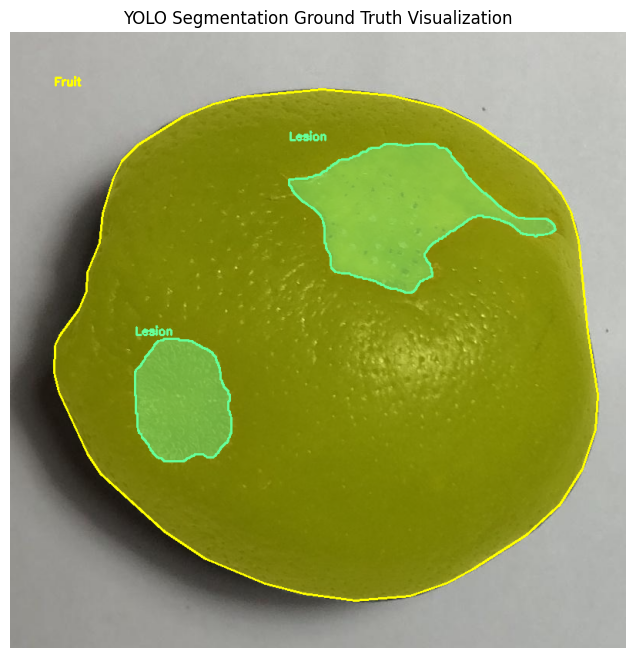

In [24]:
# get all images path
images_path = glob.glob('/content/data/small_dataset/train/images/*.jpg')

# randomly get one image path
image_path = images_path[random.randint(0, len(images_path) - 1 )]

# get the corresponding annotation file path
two_up = dir_up(dir_up(image_path))
annotation_file = image_path.split("/")[-1].split(".jpg")[0] + ".txt"
annotation_path = os.path.join(two_up, "labels", annotation_file)

# use the above defined function
visualize_yolo_segmentation_labels_with_plt(image_path, annotation_path)

### data.yaml
Edit the path in data.yaml
* change "../train/images" to "/content/data/small_dataset/train/images"
* change "../valid/images" to "/content/data/small_dataset/valid/images"
* change "../test/images" to "/content/data/small_dataset/test/images"




In [25]:
!sed -i -e 's#\.\./train/images#/content/data/small_dataset/train/images#g; \
s#\.\./valid/images#/content/data/small_dataset/valid/images#g; \
s#\.\./test/images#/content/data/small_dataset/test/images#g' \
data/small_dataset/data.yaml

# 4. Run YOLO inference on plant‑pathology images

We start with a **pretrained YOLO model** (e.g., `yolov26.pt`) and run inference on a sample image.

- The goal is to see how a generic model behaves.

In [26]:
model = YOLO("yolo26n-seg.pt")  # small, fast model suitable for demo

img_path = "/content/data/small_dataset/valid/images/b-185-_jpg.rf.e3e035bfd5949b61ea8366f0f6a9d01c.jpg"
results = model.predict(img_path, save=True)


image 1/1 /content/data/small_dataset/valid/images/b-185-_jpg.rf.e3e035bfd5949b61ea8366f0f6a9d01c.jpg: 640x640 1 orange, 15.2ms
Speed: 2.1ms preprocess, 15.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3


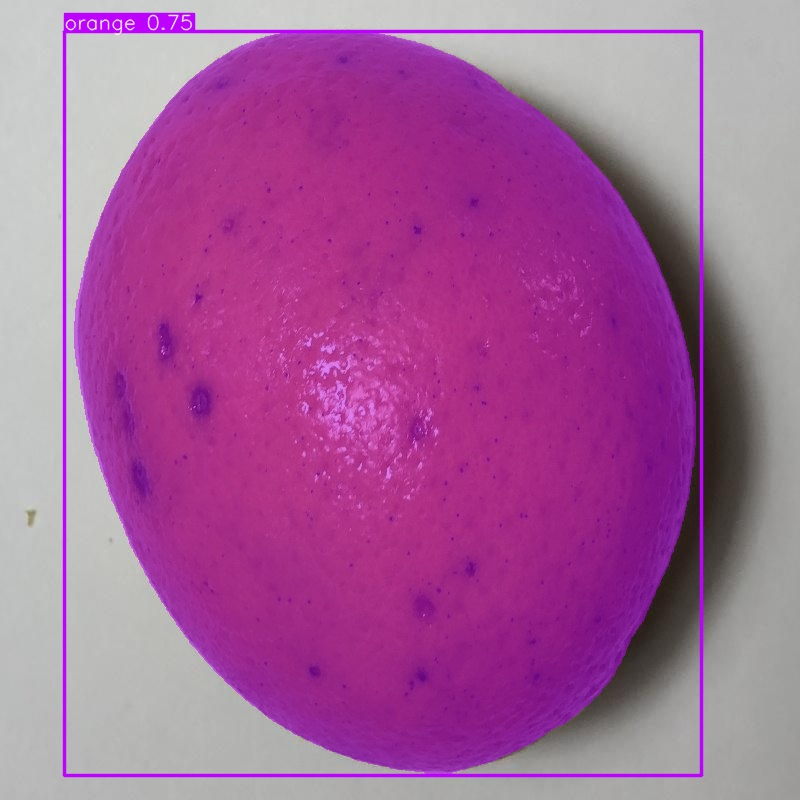

In [27]:
pred_img_path = f"{results[0].save_dir}/{img_path.split("/")[-1]}"
display(Image(filename=pred_img_path))

# 5. Understanding YOLO output

YOLO returns a `results` object containing:
- **Bounding boxes**: coordinates of detected objects.
- **Confidence scores**: how sure the model is about each detection.
- **Class labels(names)**: predicted category (e.g., person, car, etc. in the generic model).

For plant‑pathology applications, we typically train a **custom model** so that classes correspond to specific diseases, symptoms, or plant organs.

In [28]:
boxes = results[0].boxes
print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([49.], device='cuda:0')
conf: tensor([0.7518], device='cuda:0')
data: tensor([[6.4902e+01, 3.1636e+01, 7.0169e+02, 7.7515e+02, 7.5182e-01, 4.9000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (800, 800)
shape: torch.Size([1, 6])
xywh: tensor([[383.2969, 403.3920, 636.7894, 743.5114]], device='cuda:0')
xywhn: tensor([[0.4791, 0.5042, 0.7960, 0.9294]], device='cuda:0')
xyxy: tensor([[ 64.9022,  31.6364, 701.6916, 775.1477]], device='cuda:0')
xyxyn: tensor([[0.0811, 0.0395, 0.8771, 0.9689]], device='cuda:0')


In [30]:
results[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

# 6. Evaluate YOLO on multiple images

Let’s run the same pretrained model on a folder of images (batch processing)


image 1/1 /content/data/small_dataset/valid/images/c-37-_jpg.rf.227434aac058b2fe5e63c306b35e8595.jpg: 640x640 1 cake, 15.6ms
Speed: 3.0ms preprocess, 15.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-37-_jpg.rf.227434aac058b2fe5e63c306b35e8595.jpg, detections: 1


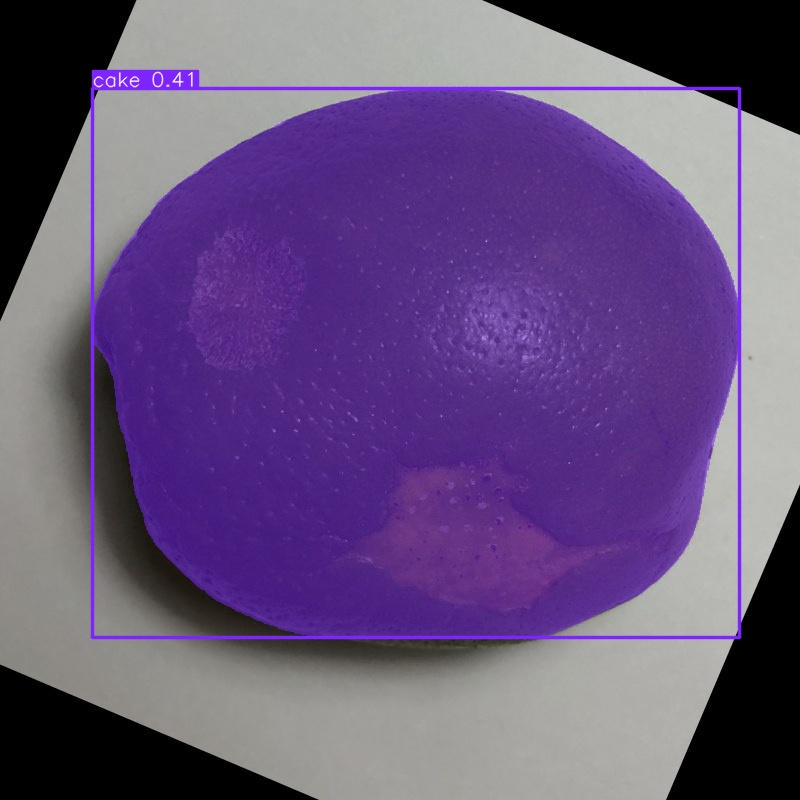


image 1/1 /content/data/small_dataset/valid/images/c-96-_jpg.rf.4dfd6a6f1734e81ccb0bcb0936b4b6fa.jpg: 640x640 1 bowl, 1 cake, 1 dining table, 15.2ms
Speed: 4.0ms preprocess, 15.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-96-_jpg.rf.4dfd6a6f1734e81ccb0bcb0936b4b6fa.jpg, detections: 3


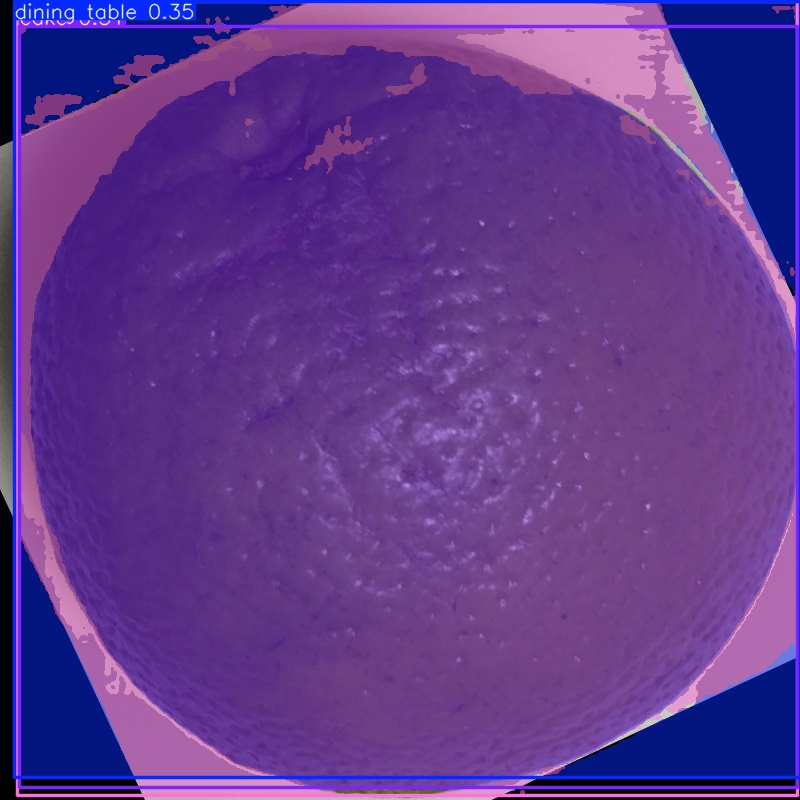


image 1/1 /content/data/small_dataset/valid/images/c-161-_jpg.rf.cc32979fdb73938866cac2045c1cdd2a.jpg: 640x640 1 orange, 31.6ms
Speed: 5.9ms preprocess, 31.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-161-_jpg.rf.cc32979fdb73938866cac2045c1cdd2a.jpg, detections: 1


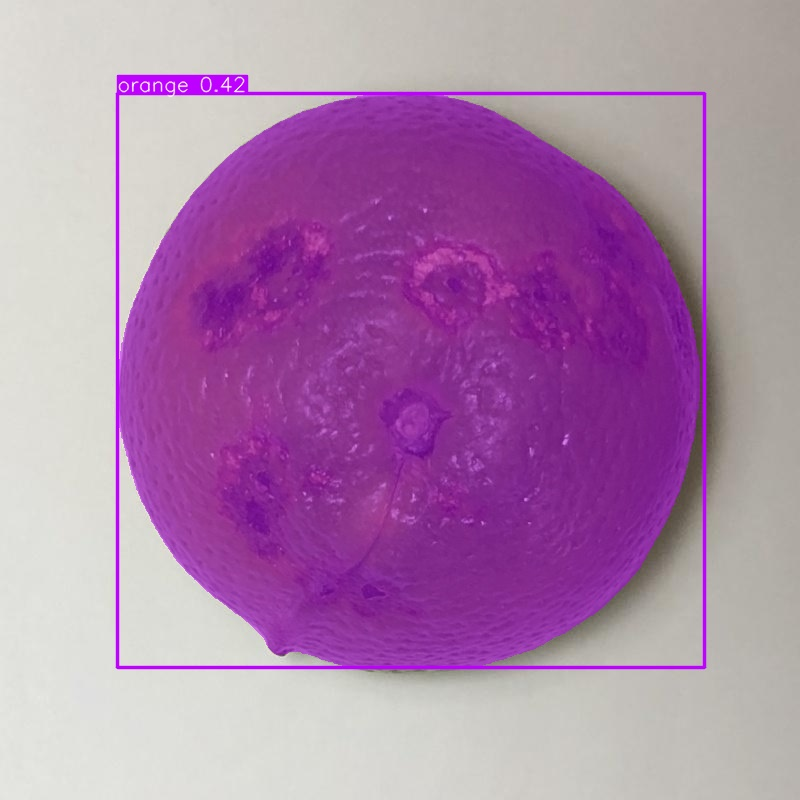


image 1/1 /content/data/small_dataset/valid/images/b-185-_jpg.rf.e3e035bfd5949b61ea8366f0f6a9d01c.jpg: 640x640 1 orange, 19.2ms
Speed: 3.9ms preprocess, 19.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: b-185-_jpg.rf.e3e035bfd5949b61ea8366f0f6a9d01c.jpg, detections: 1


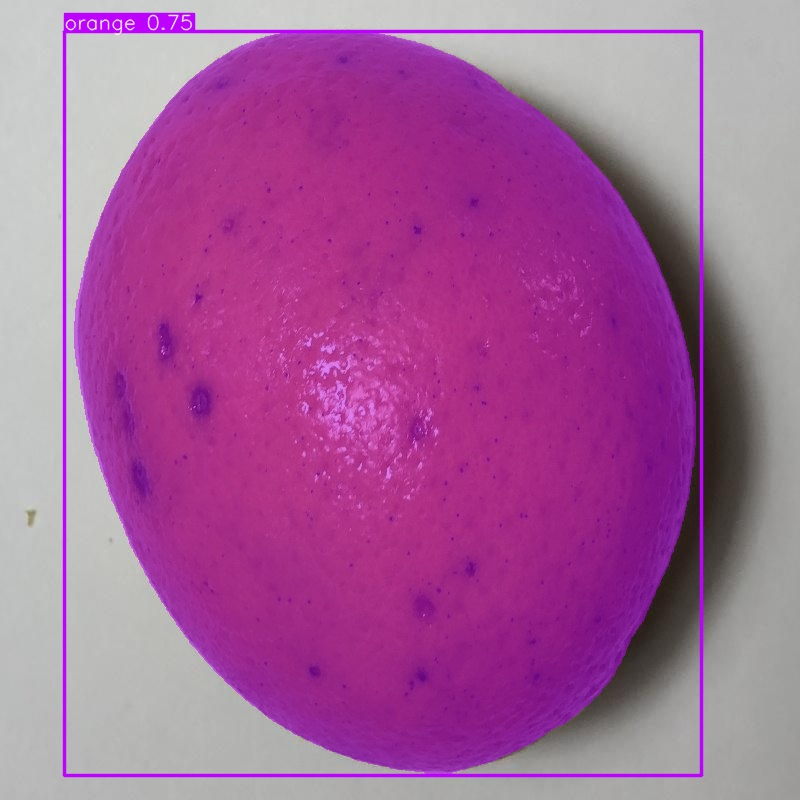


image 1/1 /content/data/small_dataset/valid/images/c-110-_jpg.rf.2f14ed8d66330b8bacbcd6f90442be61.jpg: 640x640 1 cake, 18.6ms
Speed: 3.9ms preprocess, 18.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-110-_jpg.rf.2f14ed8d66330b8bacbcd6f90442be61.jpg, detections: 1


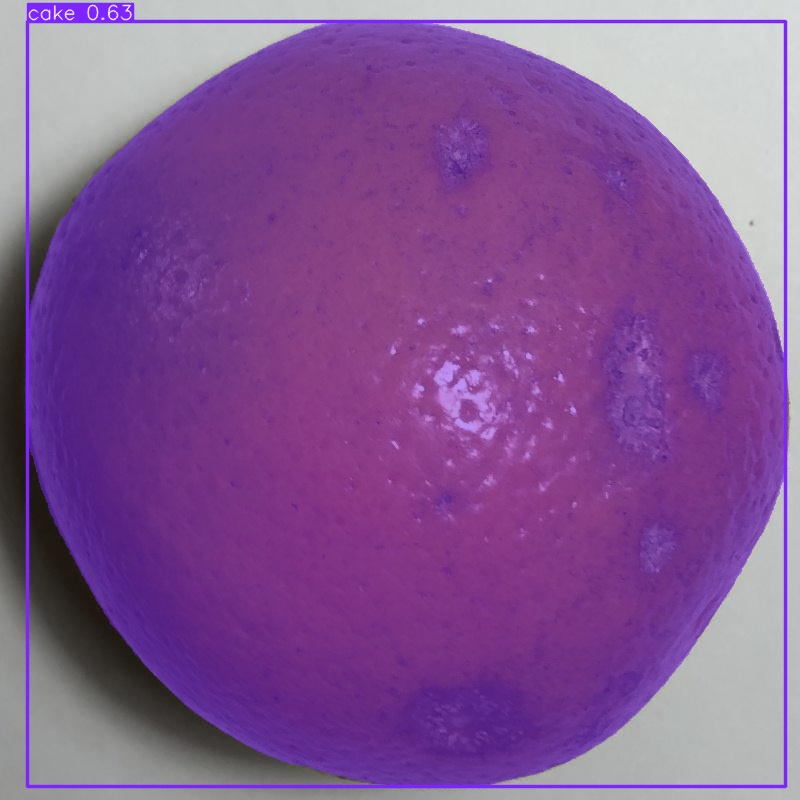


image 1/1 /content/data/small_dataset/valid/images/c-71-_jpg.rf.9dce228289d75e5da0aba3dc69dc4819.jpg: 640x640 1 bowl, 1 apple, 17.8ms
Speed: 4.4ms preprocess, 17.8ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-71-_jpg.rf.9dce228289d75e5da0aba3dc69dc4819.jpg, detections: 2


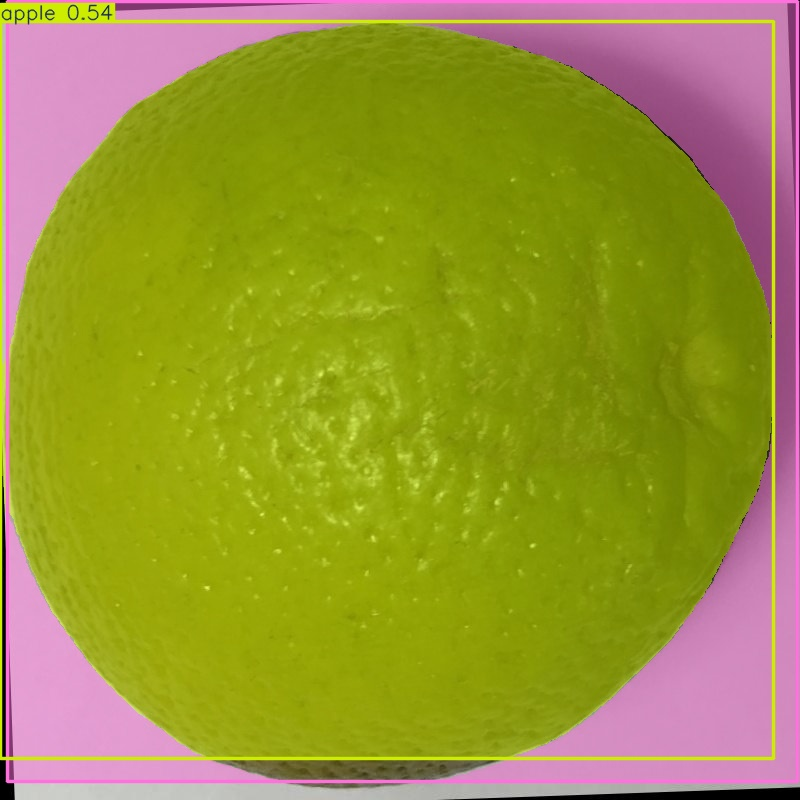


image 1/1 /content/data/small_dataset/valid/images/c-91-_jpg.rf.392232f2edcc63d06d4fc002a5836779.jpg: 640x640 1 orange, 20.8ms
Speed: 3.0ms preprocess, 20.8ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-91-_jpg.rf.392232f2edcc63d06d4fc002a5836779.jpg, detections: 1


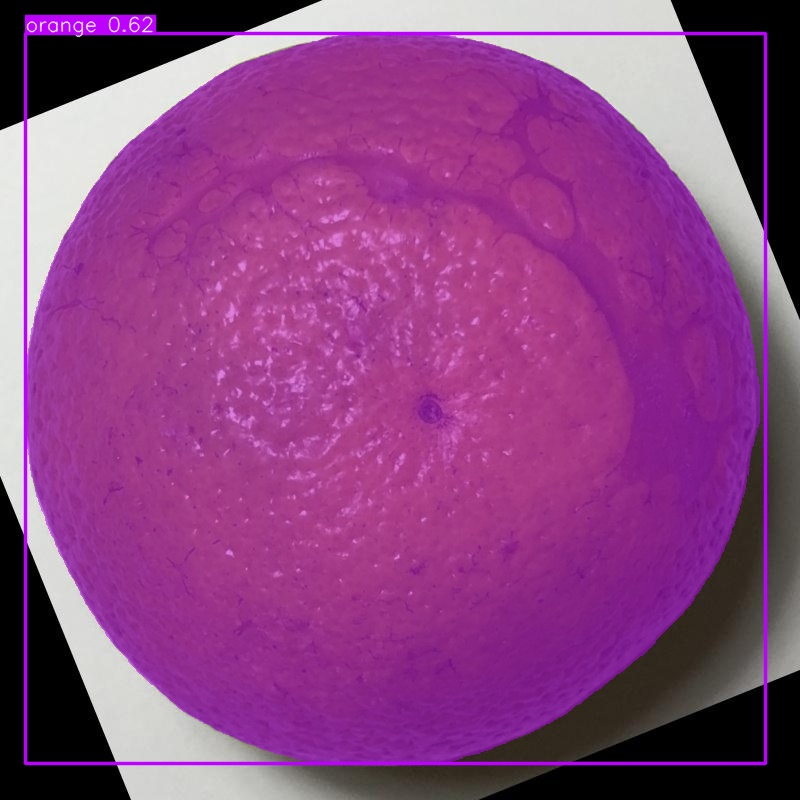


image 1/1 /content/data/small_dataset/valid/images/b-92-_jpg.rf.fd9b0e9e942f3148897dffbc7e3a250e.jpg: 640x640 1 bowl, 19.7ms
Speed: 5.1ms preprocess, 19.7ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: b-92-_jpg.rf.fd9b0e9e942f3148897dffbc7e3a250e.jpg, detections: 1


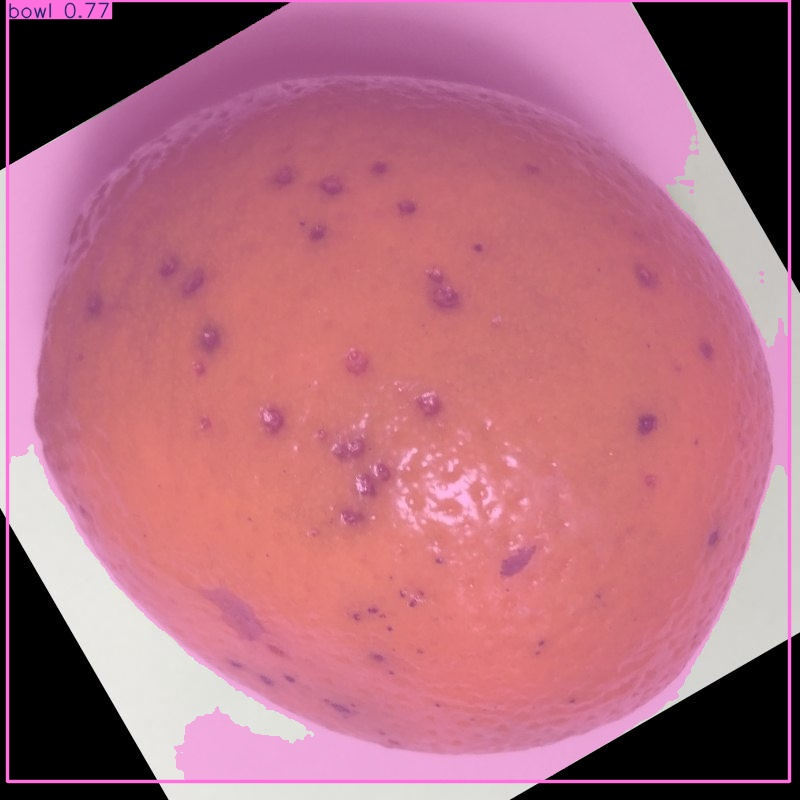


image 1/1 /content/data/small_dataset/valid/images/c-125-_jpg.rf.f423c379bdff2f347e65d6f583d23ee9.jpg: 640x640 1 orange, 20.4ms
Speed: 4.3ms preprocess, 20.4ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: c-125-_jpg.rf.f423c379bdff2f347e65d6f583d23ee9.jpg, detections: 1


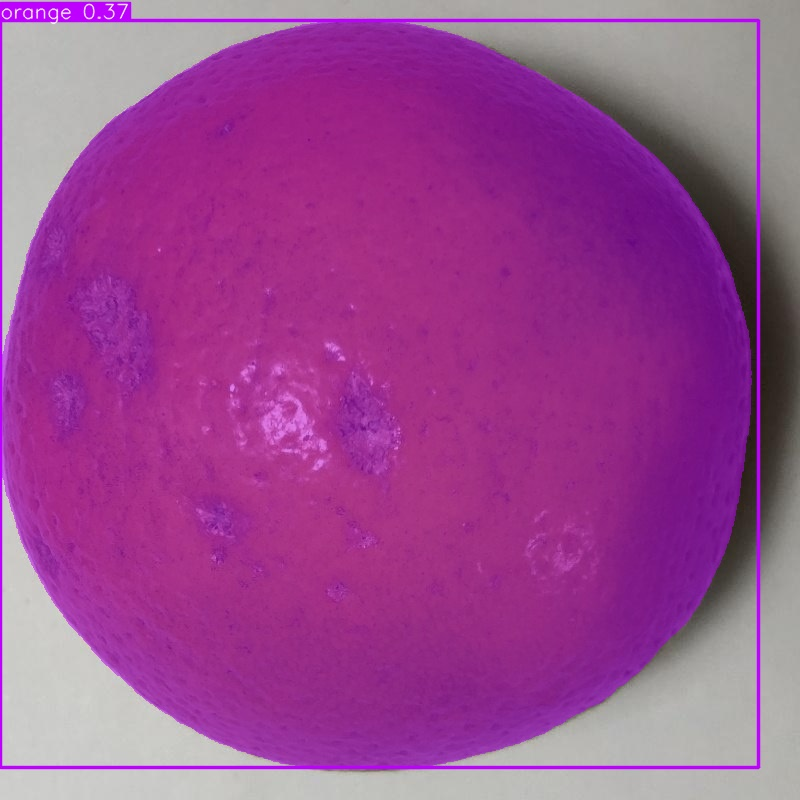


image 1/1 /content/data/small_dataset/valid/images/b-352-_jpg.rf.2919e660de629212d2f9cab2f49d5079.jpg: 640x640 1 orange, 21.8ms
Speed: 5.0ms preprocess, 21.8ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
Image: b-352-_jpg.rf.2919e660de629212d2f9cab2f49d5079.jpg, detections: 1


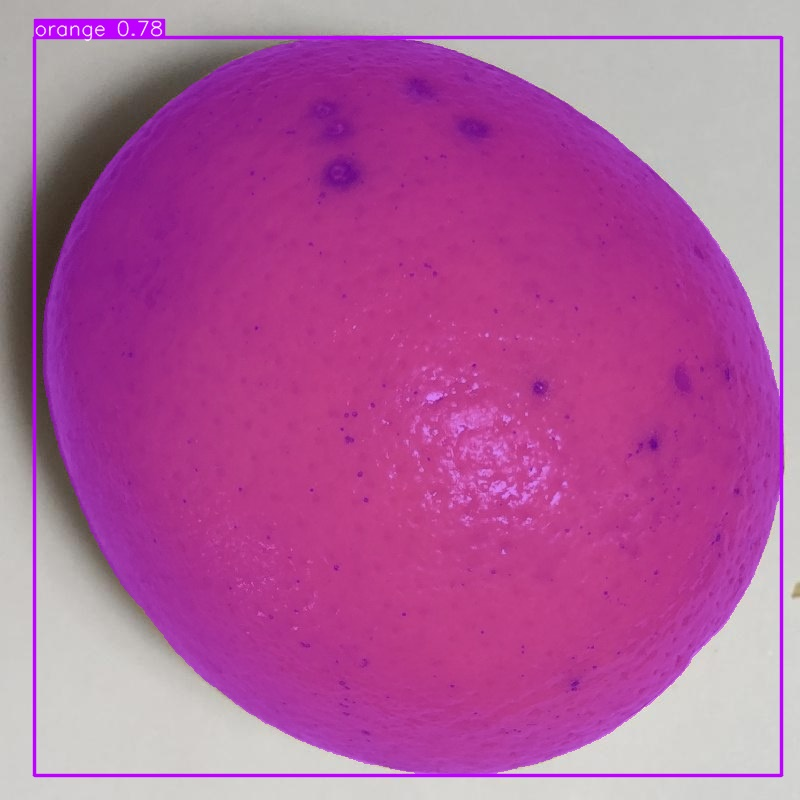

In [31]:
img_dir = "/content/data/small_dataset/valid/images/"

for img_name in os.listdir(img_dir):
    if img_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        path = os.path.join(img_dir, img_name)
        r = model.predict(path, save=True)

        print(f"Image: {img_name}, detections: {len(r[0].boxes)}")
        display(Image(filename=f"{r[0].save_dir}/{img_name}"))

# 7. Train a custom YOLO model for plant‑disease segmentation

To make YOLO truly useful for plant pathology, we train a model on a **custom dataset**.

Expected dataset structure (YOLO format):
```text
dataset/
 ├── train/
 │    ├── images/
 │    └── labels/
 ├── test/
 │    ├── images/
 │    └── labels/
 ├── valid/
 │    ├── images/
 │    └── labels/
 └── data.yaml
```

The `data.yaml` file should define:
- Paths to train/val images.
- Number of classes.
- Class names (e.g., `['healthy', 'canker', 'greasy_spot']`).

In [ ]:
!yolo checks

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 42.5/235.7 GB disk)

OS                     Linux-6.6.122+-x86_64-with-glibc2.39
Environment            Colab
Python                 3.13.15
Install                pip
Path                   /usr/local/lib/python3.13/dist-packages/ultralytics
RAM                    52.96 GB
Disk                   42.5/235.7 GB
CPU                    Intel Xeon CPU @ 2.20GHz
CPU count              12
GPU                    NVIDIA L4, 22563MiB
GPU count              1
CUDA                   13.0

numpy                  ✅ 2.1.3>=1.23.0; platform_system != "Darwin"
numpy                  ✅ 2.1.3!=2.0.*,!=2.1.*,!=2.2.*,!=2.3.0,!=2.3.1,!=2.3.2,!=2.3.3,!=2.3.4,>=1.23.0; platform_system == "Darwin"
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 5.0.0.93!=4.13.0.90,>=4.7.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               

In [33]:
# Load a model

from ultralytics import YOLO
model = YOLO("yolo26n-seg.pt")  # load a pretrained model (recommended for training)

# Train the model
train_results = model.train(
    data="/content/data/small_dataset/data.yaml",
    epochs=100, # number of training epochs
    imgsz=640,
    batch=8,
    resume=False, # True, if contuniue the interupted train, but model=YOLO("PATH/TO/last.pt")
    device=0 # device="cpu", or device=0 or device=0,1,2,3 for multiple GPU
    )

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/small_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize

# 8. Visualize training metrics

Ultralytics saves training curves (loss, mAP, precision/recall) in the run directory. We can display the summary image.

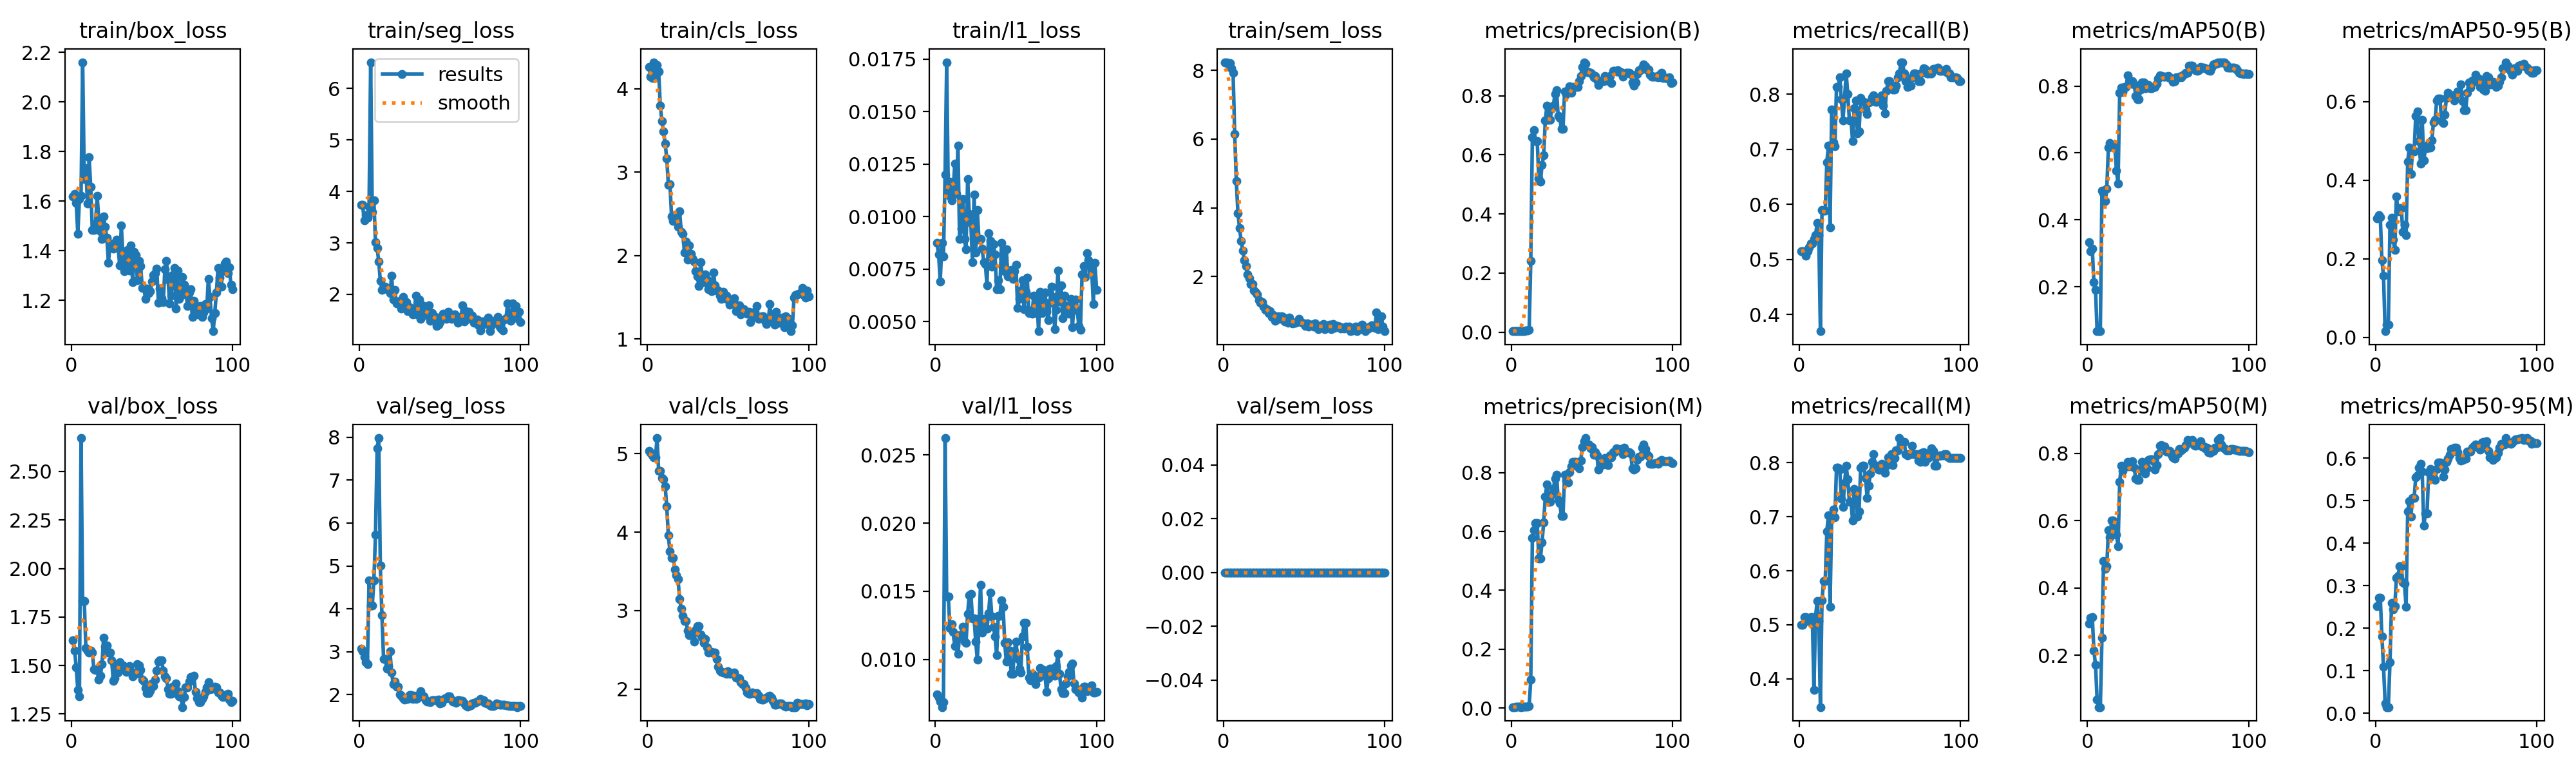

In [36]:
results_img = "/content/runs/segment/train/results.png"
if os.path.exists(results_img):
    display(Image(filename=results_img, width=1000))
else:
    print("Training results image not found. Check your run directory.")

### What each loss means

| Loss | What it trains | Intuition |  Value changes |
|---|---|---|---|
| **`box_loss`** | Bounding-box localization | Did I put the box in the right place? | ~1.6 → ~1.1 |
| **`seg_loss`** | Instance segmentation masks | Did I outline each object correctly? | ~3.6 → ~1.4 |
| **`cls_loss`** | Object classification | Did I assign the correct class? | ~4.2 → ~1.1 |
| **`l1_loss`** | Fine-grained localization | How far are my predicted box coordinates from the target? | ~0.010 → ~0.005 |
| **`sem_loss`** | Semantic segmentation | Did I classify pixels/regions correctly? | ~8 → ~0.4 |

- mAP50, Calculate mAP using IoU ≥ 0.50. Did the model basically find the object correctly?
- mAP50-95 = "How precisely did the model locate/segment the object?"


# 9. Evaluate the custom model

We can run validation to compute metrics on the validation set defined in `data.yaml`, although train step has automatically evaluated the val dataset

In [35]:
metrics = model.val()


Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 136 layers, 2,689,274 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2051.1±449.3 MB/s, size: 52.5 KB)
val: Scanning /content/data/small_dataset/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s
                   all         10         78      0.894      0.838       0.87      0.699      0.885      0.819       0.84      0.642
                 fruit         10         10      0.984          1      0.995      0.949      0.987          1      0.995      0.969
                lesion         10         68      0.804      0.676      0.745       0.45      0.783      0.639      0.685      0.315
Speed: 0.5ms preprocess, 14.5ms infere

In [ ]:
metrics.results_dict

{'metrics/precision(B)': 0.8421078313926615,
 'metrics/recall(B)': 0.8529411764705883,
 'metrics/mAP50(B)': 0.8436672035131451,
 'metrics/mAP50-95(B)': 0.6913186827188691,
 'metrics/precision(M)': 0.8294750103262704,
 'metrics/recall(M)': 0.8382352941176471,
 'metrics/mAP50(M)': 0.8135180034830447,
 'metrics/mAP50-95(M)': 0.6306009026824608,
 'fitness': 1.32191958540133}

# 10. Apply the custom model to new images

Now we use the trained model to predict on new, unseen images (e.g., test images or field samples).

In [ ]:
!ls /content/runs/segment/train/weights
# model = YOLO("/content/runs/segment/train/weights/best.pt") # load the best model if it is not available in memory

best.pt  last.pt



image 1/1 /content/data/small_dataset/test/images/b-121-_jpg.rf.32a36b5c4d8dc98190cd6ff22c1b1dbe.jpg: 640x640 1 fruit, 25 lesions, 12.5ms
Speed: 2.2ms preprocess, 12.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2


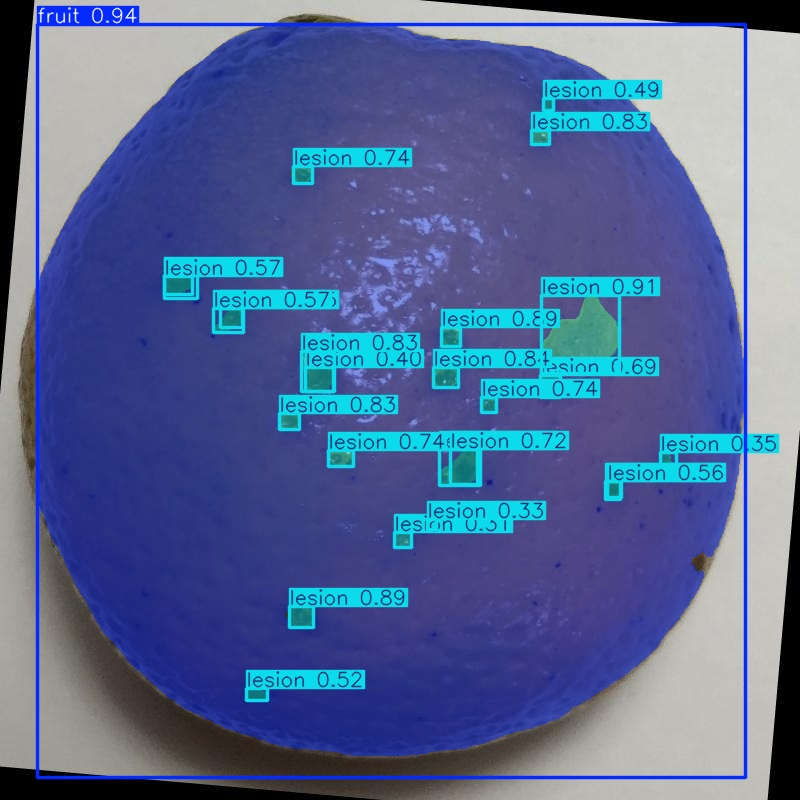

In [ ]:
test_img_path = "/content/data/small_dataset/test/images/b-121-_jpg.rf.32a36b5c4d8dc98190cd6ff22c1b1dbe.jpg"  # change to your own image
test_results = model.predict(test_img_path, save=True)

pred_img_path = f"{test_results[0].save_dir}/{test_img_path.split("/")[-1]}"
display(Image(filename=pred_img_path))


image 1/1 /content/data/small_dataset/test/images/b-184-_jpg.rf.625830e7bca0940b0a5ba163ac787630.jpg: 640x640 1 fruit, 5 lesions, 14.5ms
Speed: 2.3ms preprocess, 14.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-184-_jpg.rf.625830e7bca0940b0a5ba163ac787630.jpg, detections: 6


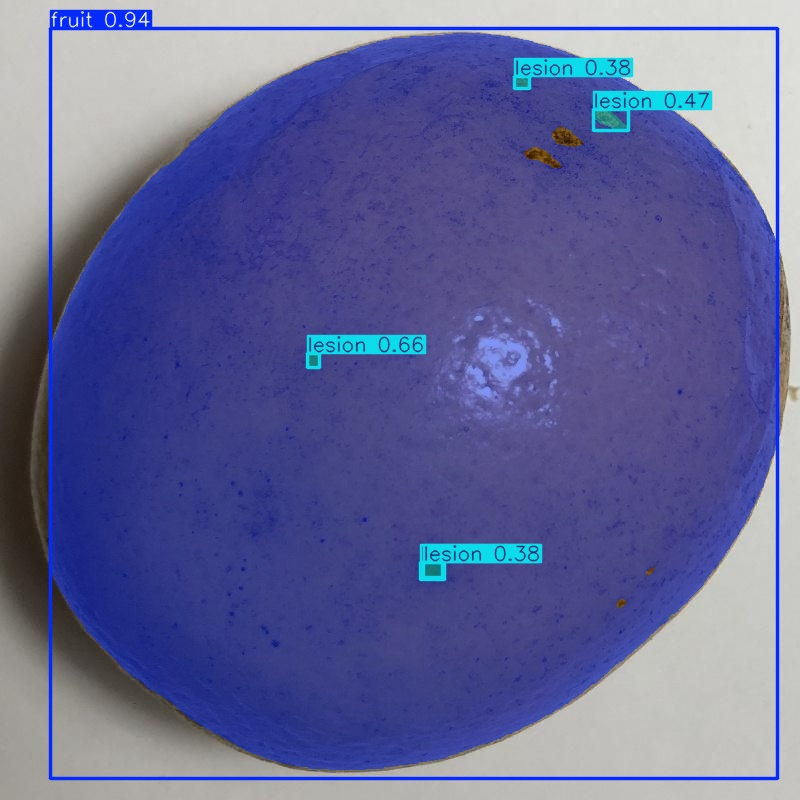


image 1/1 /content/data/small_dataset/test/images/b-126-_jpg.rf.85521dca81a31b2378977cad9da0a9c4.jpg: 640x640 1 fruit, 21 lesions, 15.1ms
Speed: 2.2ms preprocess, 15.1ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-126-_jpg.rf.85521dca81a31b2378977cad9da0a9c4.jpg, detections: 22


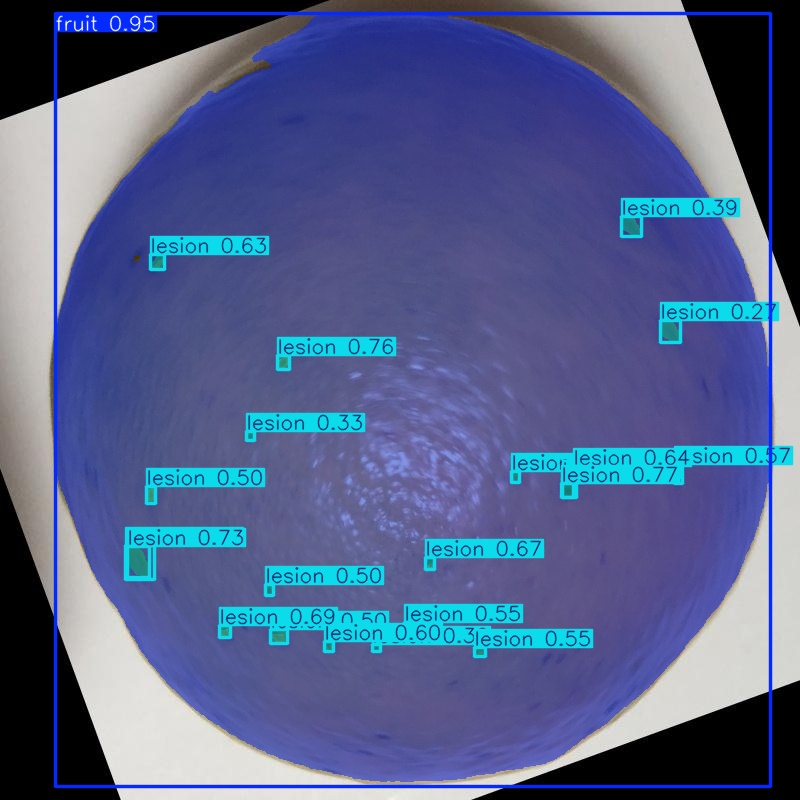


image 1/1 /content/data/small_dataset/test/images/c-292-_jpg.rf.421cddf5d33fdaa7dbb3386595cf2e29.jpg: 640x640 1 fruit, 6 lesions, 13.4ms
Speed: 2.1ms preprocess, 13.4ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: c-292-_jpg.rf.421cddf5d33fdaa7dbb3386595cf2e29.jpg, detections: 7


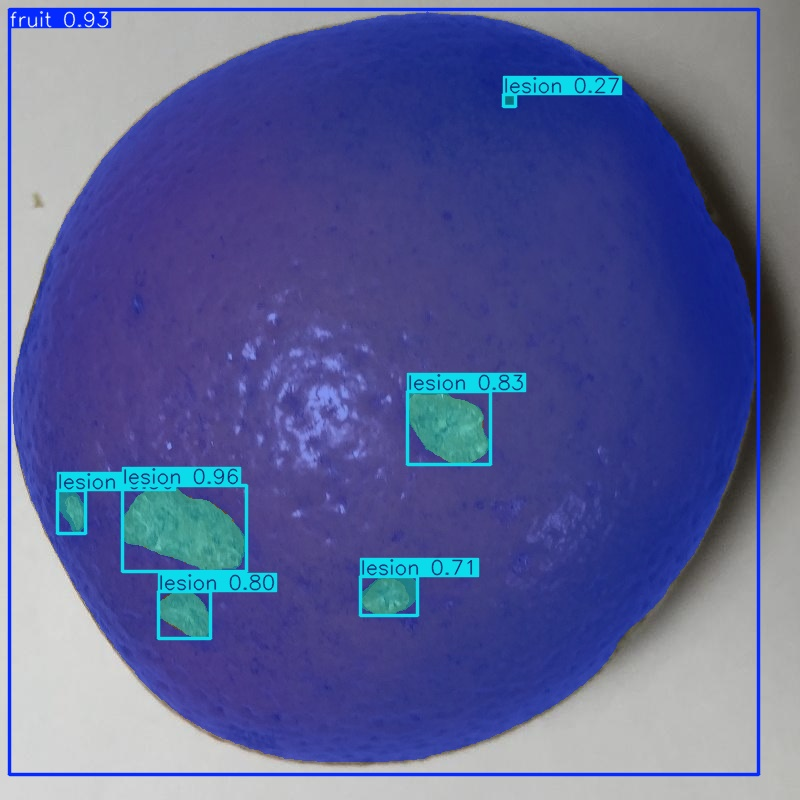


image 1/1 /content/data/small_dataset/test/images/b-192-_jpg.rf.2622b8ddb3059ff8c8757bdfa278eded.jpg: 640x640 1 fruit, 29 lesions, 16.1ms
Speed: 3.0ms preprocess, 16.1ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-192-_jpg.rf.2622b8ddb3059ff8c8757bdfa278eded.jpg, detections: 30


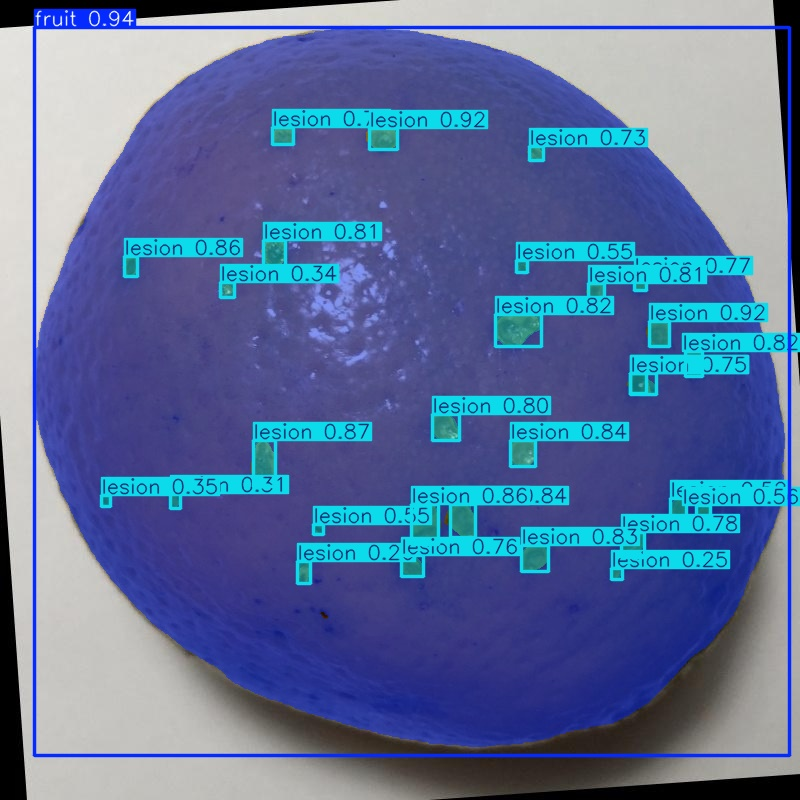


image 1/1 /content/data/small_dataset/test/images/b-342-_jpg.rf.e4fbfbde67440a904e44fad62323d0c9.jpg: 640x640 1 fruit, 11 lesions, 17.2ms
Speed: 2.1ms preprocess, 17.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-342-_jpg.rf.e4fbfbde67440a904e44fad62323d0c9.jpg, detections: 12


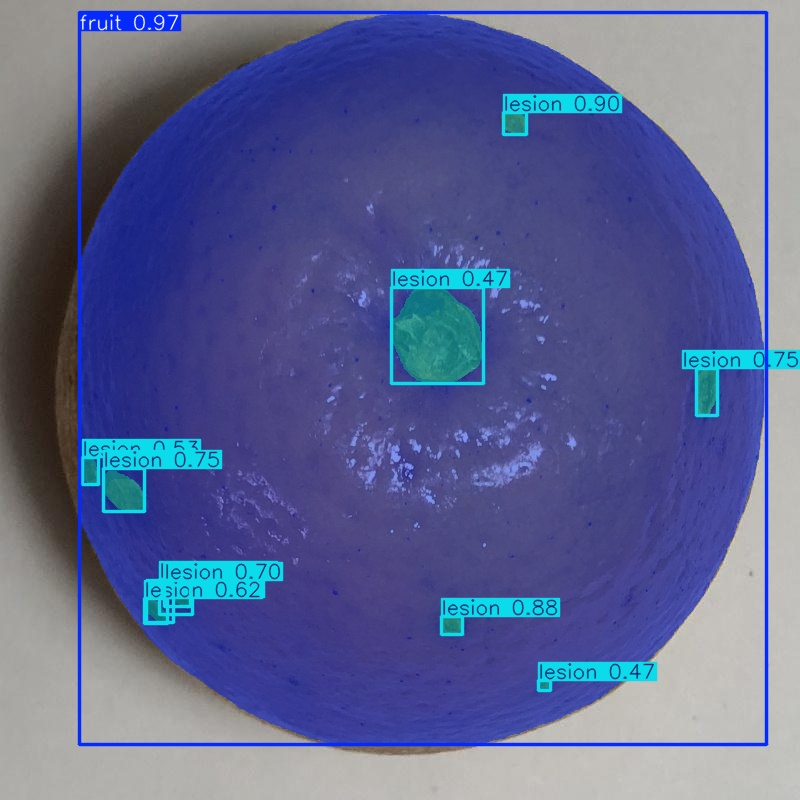


image 1/1 /content/data/small_dataset/test/images/b-139-_jpg.rf.d39413985f821b849697157f247552c6.jpg: 640x640 1 fruit, 21 lesions, 13.7ms
Speed: 2.1ms preprocess, 13.7ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-139-_jpg.rf.d39413985f821b849697157f247552c6.jpg, detections: 22


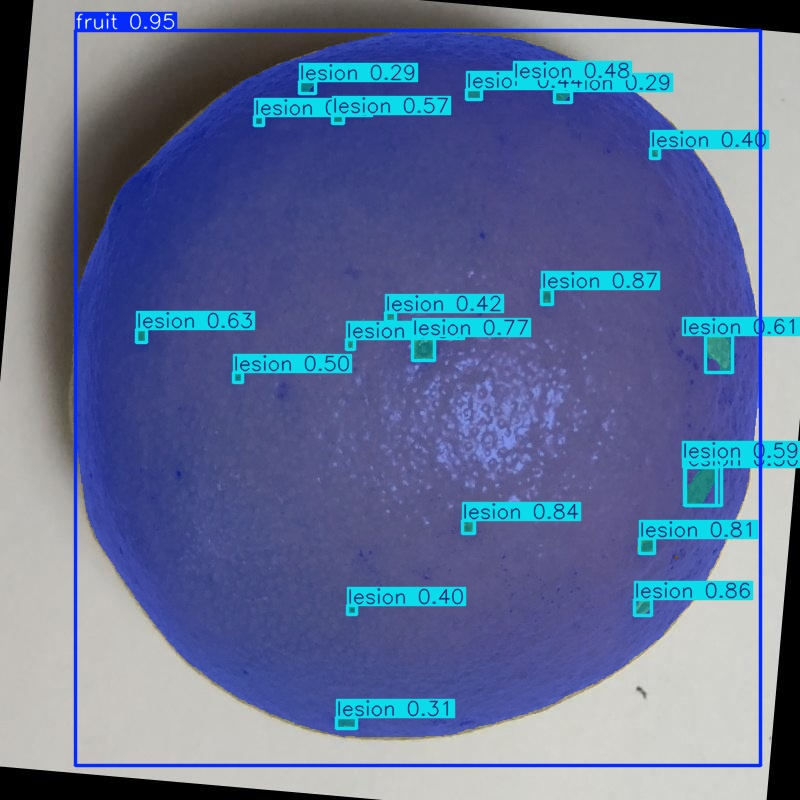


image 1/1 /content/data/small_dataset/test/images/b-189-_jpg.rf.abe5e19d823305f5854de8b019c108f8.jpg: 640x640 1 fruit, 11 lesions, 13.6ms
Speed: 2.1ms preprocess, 13.6ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-189-_jpg.rf.abe5e19d823305f5854de8b019c108f8.jpg, detections: 12


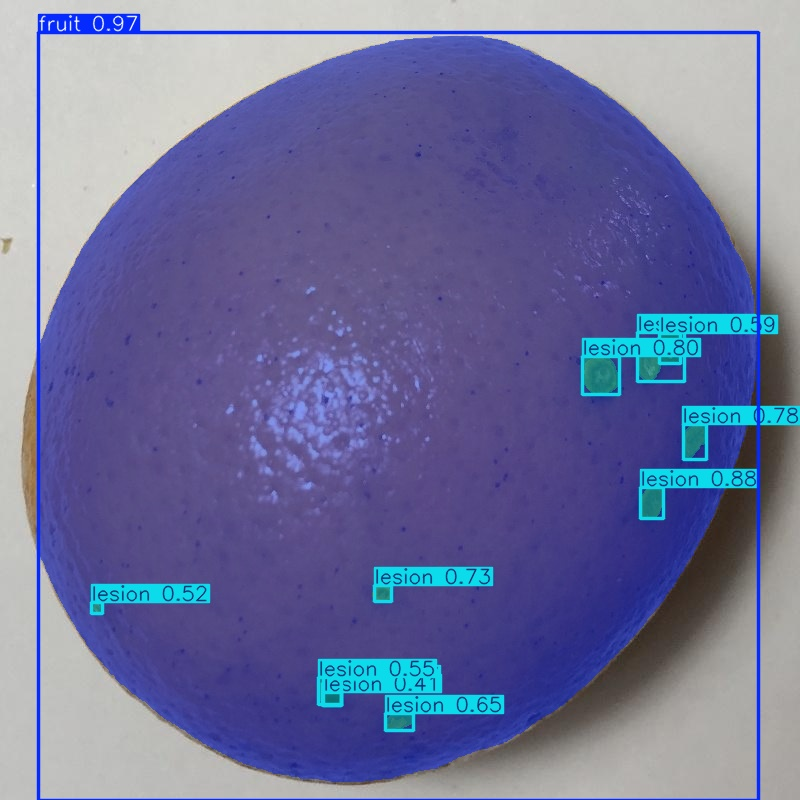


image 1/1 /content/data/small_dataset/test/images/b-309-_jpg.rf.c15bd7bdf7d2670f4505f5c8a385cbb7.jpg: 640x640 1 fruit, 15 lesions, 14.9ms
Speed: 2.3ms preprocess, 14.9ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-309-_jpg.rf.c15bd7bdf7d2670f4505f5c8a385cbb7.jpg, detections: 16


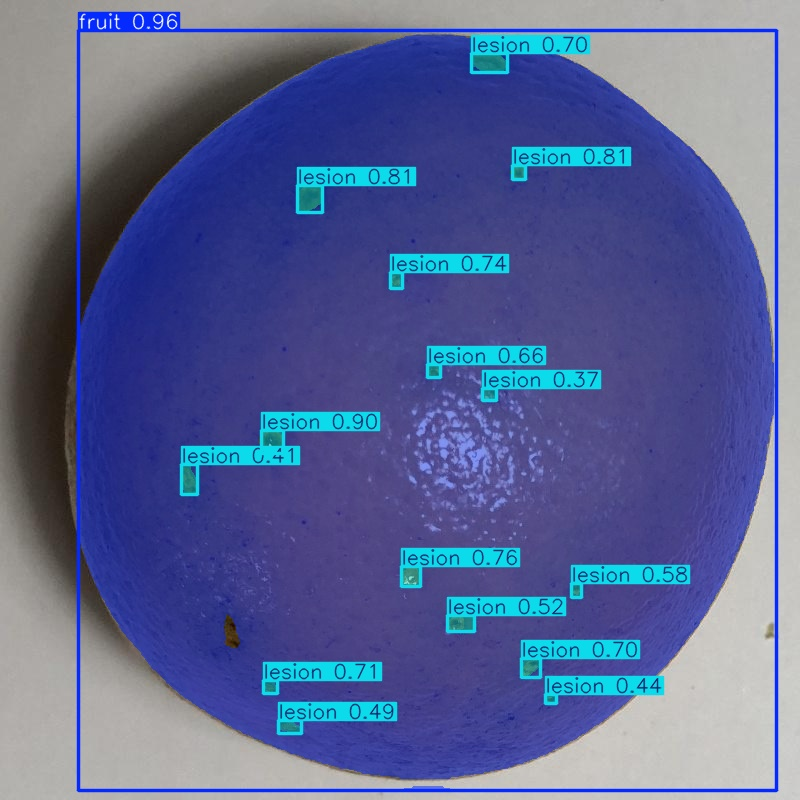


image 1/1 /content/data/small_dataset/test/images/b-128-_jpg.rf.99bbb979b8243d8fd567dde5747d88ec.jpg: 640x640 1 fruit, 15 lesions, 15.9ms
Speed: 2.2ms preprocess, 15.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-128-_jpg.rf.99bbb979b8243d8fd567dde5747d88ec.jpg, detections: 16


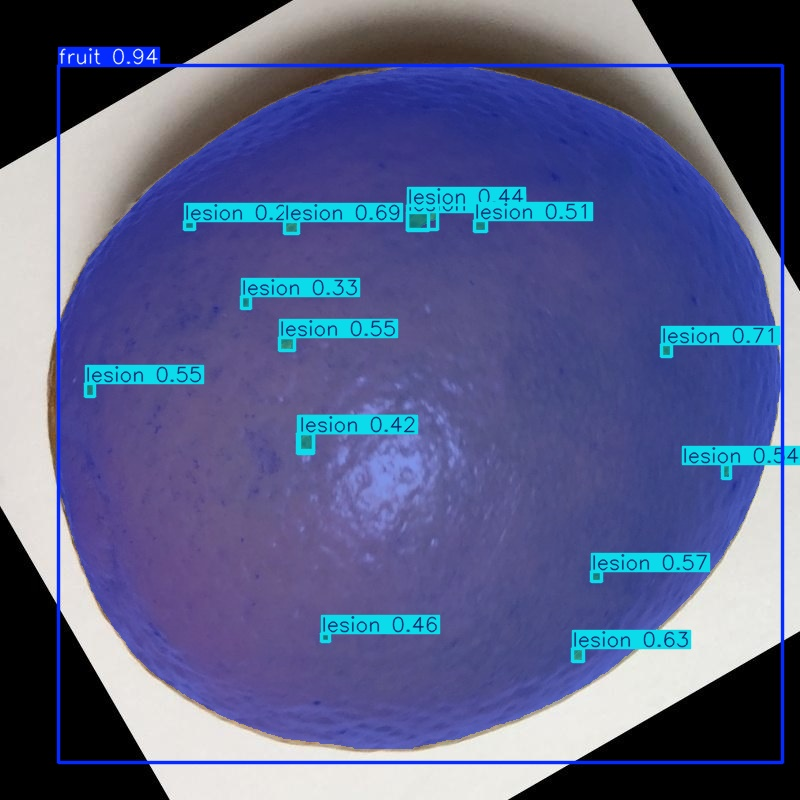


image 1/1 /content/data/small_dataset/test/images/b-45-_jpg.rf.880e8b7712a152e4fc8200130bb31499.jpg: 640x640 1 fruit, 7 lesions, 14.5ms
Speed: 2.2ms preprocess, 14.5ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-45-_jpg.rf.880e8b7712a152e4fc8200130bb31499.jpg, detections: 8


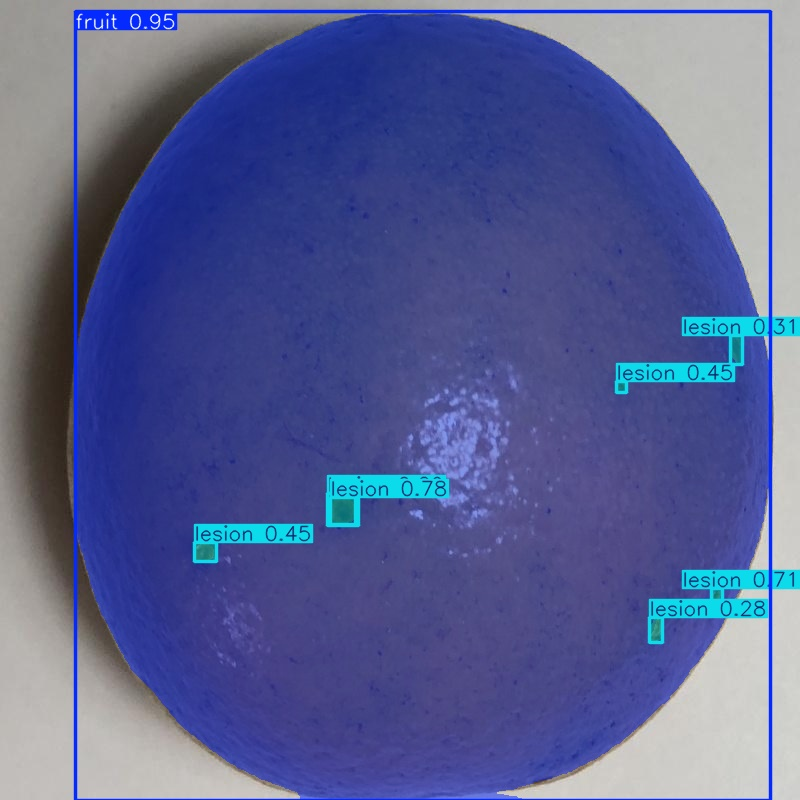


image 1/1 /content/data/small_dataset/test/images/b-121-_jpg.rf.32a36b5c4d8dc98190cd6ff22c1b1dbe.jpg: 640x640 1 fruit, 25 lesions, 14.6ms
Speed: 2.3ms preprocess, 14.6ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-121-_jpg.rf.32a36b5c4d8dc98190cd6ff22c1b1dbe.jpg, detections: 26


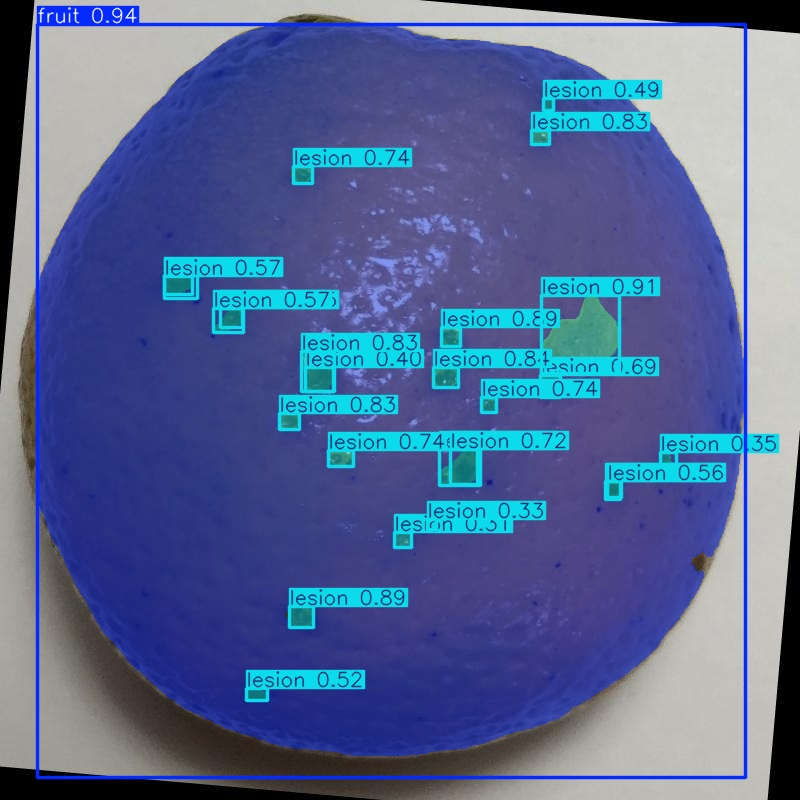


image 1/1 /content/data/small_dataset/test/images/b-213-_jpg.rf.bec088869e2d839f8b30914cfe66e536.jpg: 640x640 1 fruit, 24 lesions, 15.0ms
Speed: 2.3ms preprocess, 15.0ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2
Image: b-213-_jpg.rf.bec088869e2d839f8b30914cfe66e536.jpg, detections: 25


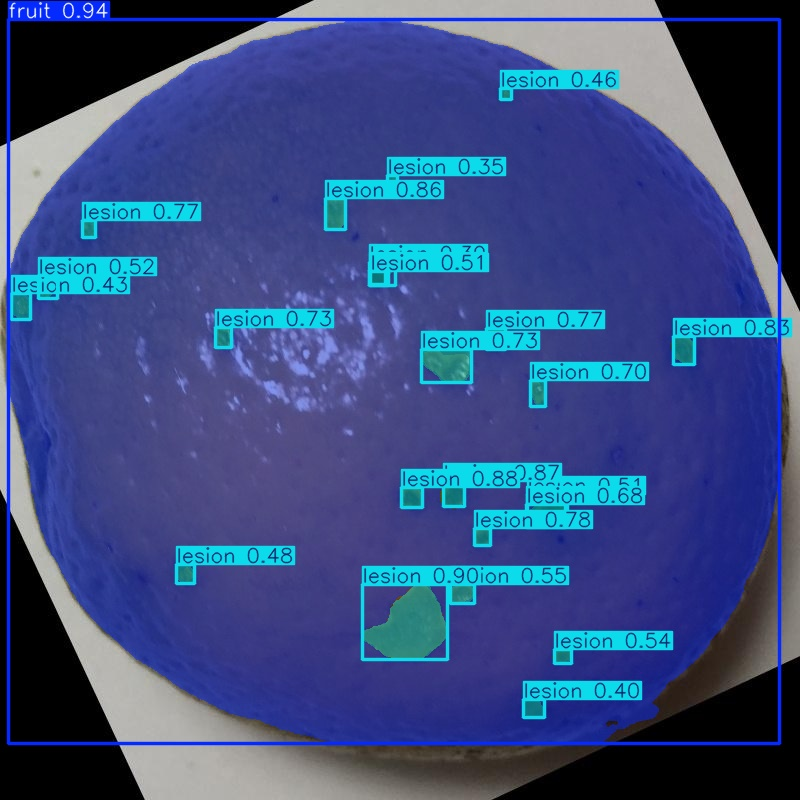

In [ ]:
# batch predicting
img_dir = "/content/data/small_dataset/test/images/"

for img_name in os.listdir(img_dir):
    if img_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        path = os.path.join(img_dir, img_name)
        r = model.predict(path, save=True)

        print(f"Image: {img_name}, detections: {len(r[0].boxes)}")
        display(Image(filename=f"{r[0].save_dir}/{img_name}"))

# 11. Post analysis

In [ ]:
res = test_results[0]

**Extracting bounding polygons**

Use 'Masks.xyn' for segments (normalized) and 'Masks.xy' for segments (pixels)

In [ ]:
res.masks.xyn

[array([[     0.3375,     0.03125],
        [    0.33594,    0.032812],
        [    0.32969,    0.032812],
        ...,
        [    0.49531,    0.032812],
        [     0.4875,    0.032812],
        [    0.48594,     0.03125]], dtype=float32),
 array([[    0.73125,     0.37031],
        [    0.72969,     0.37187],
        [    0.72969,       0.375],
        [    0.72812,     0.37656],
        [    0.72812,     0.38125],
        [    0.72656,     0.38281],
        [    0.72656,     0.38594],
        [      0.725,      0.3875],
        [      0.725,     0.39062],
        [    0.72344,     0.39219],
        [    0.72344,     0.39375],
        [    0.71875,     0.39844],
        [    0.70156,     0.39844],
        [    0.69219,     0.40781],
        [    0.69219,     0.40938],
        [     0.6875,     0.41406],
        [     0.6875,     0.41563],
        [    0.68437,     0.41875],
        [    0.68437,     0.42031],
        [    0.68125,     0.42344],
        [    0.67969,     0.42344]

**Extracting segmented masks**

In [ ]:
extracted_masks = res.masks.data

In [ ]:
extracted_masks.shape

torch.Size([26, 640, 640])

Push the mask to cpu (from GPU) and convert to numpy array for easy plotting.

In [ ]:
masks_array = extracted_masks.cpu().numpy()

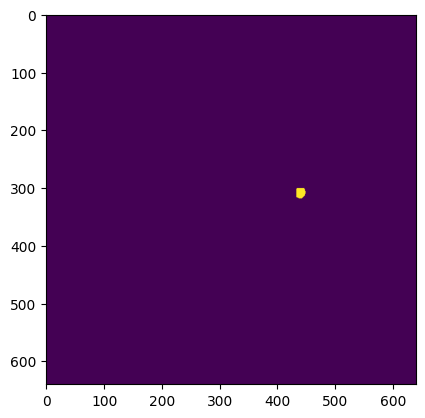

In [ ]:
random_mask = np.random.choice( extracted_masks.shape[0]) # .choice not include the end point

plt.imshow(masks_array[random_mask])

**Extracting labels for each class**

In [ ]:
class_names = res.names.values()
class_names

dict_values(['fruit', 'lesion'])

In [ ]:
# Extract the boxes, which likely contain class IDs
detected_boxes =  res.boxes.data
# Extract class IDs from the detected boxes
class_labels = detected_boxes[:, -1].int().tolist()
# Initialize a dictionary to hold masks by class
masks_by_class = {name: [] for name in  res.names.values()}

# Iterate through the masks and class labels
for mask, class_id in zip(extracted_masks, class_labels):
    class_name =  res.names[class_id]  # Map class ID to class name
    masks_by_class[class_name].append(mask.cpu().numpy())

In [ ]:
for class_name, masks in masks_by_class.items():
    print(f"Class Name: {class_name}, Number of Masks: {len(masks)}")

Class Name: fruit, Number of Masks: 1
Class Name: lesion, Number of Masks: 25


**Extracting masks for a specific class**

In [ ]:
orange_masks = masks_by_class['fruit']
lesion_masks = masks_by_class['lesion']

In [ ]:
# Extract the original image
orig_img = res.orig_img

In [ ]:
orig_img.shape

(800, 800, 3)

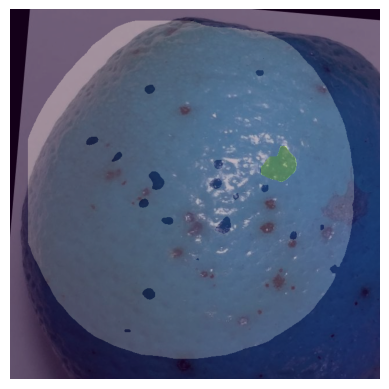

In [ ]:
# Display the original image
plt.imshow(orig_img, cmap='gray')

# Overlay the mask with some transparency
plt.imshow(orange_masks[0], cmap='magma', alpha=0.3)
plt.imshow(lesion_masks[0], cmap='viridis', alpha=0.3)
plt.axis('off') # Turn off axis labels
plt.show()

**Calculating region properties for all objects and saving to a csv file.**

In [ ]:
from skimage.measure import regionprops

# Initialize a list to store the properties
props_list = []

# Iterate through all classes
for class_name, masks in masks_by_class.items():
    # Iterate through the masks for this class
    for mask in masks:
        # Convert the mask to an integer type if it's not already
        mask = mask.astype(int)

        # Apply regionprops to the mask
        props = regionprops(mask)

        # Extract the properties you want (e.g., area, perimeter) and add them to the list
        for prop in props:
            area = prop.area
            perimeter = prop.perimeter
            # Add other properties as needed

            # Append the properties and class name to the list
            props_list.append({'Class Name': class_name, 'Area': area, 'Perimeter': perimeter})

# Convert the list of dictionaries to a DataFrame
props_df = pd.DataFrame(props_list)

# Now props_df contains the properties and class names for all regions

# Save the DataFrame to a CSV file
props_df.to_csv('object_properties.csv', index=False)

In [ ]:
props_df

,Class Name,Area,Perimeter
0,fruit,264489.0,3120.380085
1,lesion,2472.0,201.237590
2,lesion,313.0,64.727922
3,lesion,218.0,53.656854
4,lesion,292.0,62.727922
5,lesion,198.0,51.656854
6,lesion,680.0,103.355339
7,lesion,143.0,43.071068
8,lesion,121.0,39.656854
9,lesion,238.0,59.071068


**Plotting region property results**

In [ ]:
import seaborn as sns

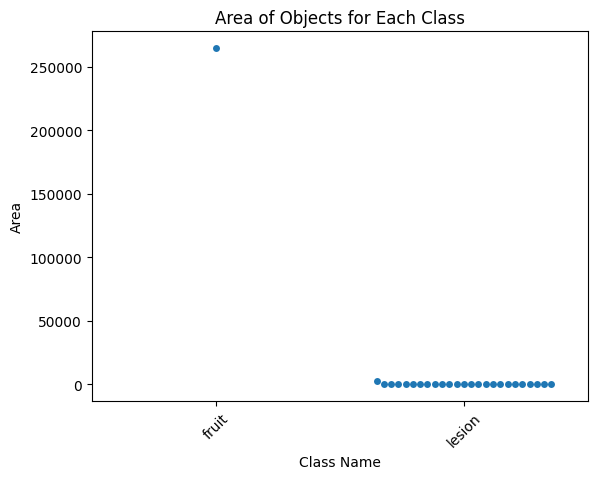

In [ ]:
# Create the swarm plot with Seaborn
sns.swarmplot(x='Class Name', y='Area', data=props_df)

# Add labels and a title
plt.xlabel('Class Name')
plt.ylabel('Area')
plt.title('Area of Objects for Each Class')

# Rotate the x-axis labels for better visibility if needed
plt.xticks(rotation=45)

# Show the plot
plt.show()

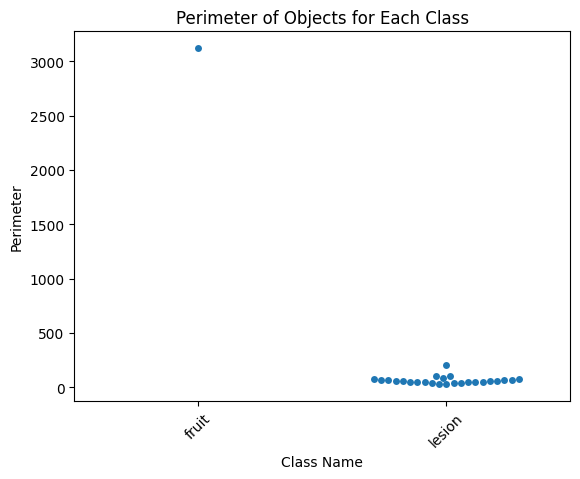

In [ ]:
# Create the swarm plot with Seaborn
sns.swarmplot(x='Class Name', y='Perimeter', data=props_df)

# Add labels and a title
plt.xlabel('Class Name')
plt.ylabel('Perimeter')
plt.title('Perimeter of Objects for Each Class')

# Rotate the x-axis labels for better visibility if needed
plt.xticks(rotation=45)

# Show the plot
plt.show()

# 12. Summary

In this notebook, you:
- Learned what YOLO is and the tasks it supports.
- Ran YOLO inference on plant‑pathology images.
- Trained and evaluated a custom YOLO model.
- Summarized statistics and post analysis.
- Connect YOLO capabilities to real plant‑pathology research questions.